# **Mini-projet Deep Learning**
### *Classification d’images par réseaux de neurones convolutionnels*

Clara Gambardello

### **Importation des packages**

In [ ]:
# Packages standards
import os
import numpy as np

# Traitement d’images
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

Pour assurer la reproductibilité des résultats, on fixe une seed pour NumPy et TensorFlow.
Cela permet d’obtenir les mêmes résultats d’une exécution à l’autre (dans un même ordre de grandeur), notamment pour le découpage des données et l’initialisation du réseau (poids).

In [ ]:
np.random.seed(19)
tf.random.set_seed(19)

### **Les fonctions utiles**

Fonction qui permet d'afficher une image du jeu de données train ou test :

In [ ]:
def plot_img_lab(idx, race, X_train, y_train, X_test, y_test, data="test"):

    if data == "train" :
        df = X_train*255
        lab = y_train
    else :
        df = X_test*255
        lab = y_test

    title = lab[idx]
    ohe = np.where(title == 1)[0][0]
    title_eff = race[ohe]

    plt.imshow(df[idx].astype("uint8"))
    plt.title(f"Label : {title_eff}")
    plt.axis(False)
    plt.show()

Fonction qui permet de tracer les courbes de l'accucary et de la loss pour le jeu de validation et le jeu train :

In [ ]:
def plot_loss_accuracy(history_mod):

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(history_mod.history["val_loss"], label="validation")
    axes[0].plot(history_mod.history["loss"], label="train")
    axes[0].set_title("Fonction de perte (loss)")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Categorical Cross-Entropy")
    axes[0].set_ylim(-0.05, 10)
    axes[0].legend()

    axes[1].plot(history_mod.history["val_accuracy"], label="validation")
    axes[1].plot(history_mod.history["accuracy"], label="train")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Categorical Cross-Entropy")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()

    plt.show()

Fonction qui permet de tracer des matrice de confusions :

In [ ]:
def plot_confusion_matrices_onehot(y_true, y_pred):

    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)

    mat_conf = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(mat_conf, annot=True, fmt='d', cmap='Reds', ax=axes[0])
    axes[0].set_title("Matrice de confusion")
    axes[0].set_xlabel("Prédit")
    axes[0].set_ylabel("Réel")

    mat_conf_perc = mat_conf.astype('float') / mat_conf.sum(axis=1)[:, np.newaxis]*100
    sns.heatmap(mat_conf_perc, annot=True, fmt=".1f", cmap='Reds', ax=axes[1])
    axes[1].set_title("Matrice de confusion (en %)")
    axes[1].set_xlabel("Prédit")
    axes[1].set_ylabel("Réel")

    plt.show()

### **Préparation des données et découpage en échantillons train et test**

In [ ]:
race = ["Cairn", "Chihuahua", "Dingo", "Pyrenees", "Samoyed"]
chemin_perso = "/content/drive/MyDrive/Clara/Images_Small"

X = []
target = []

# Boucle pour ajouter les images à la liste image avec le label qui lui correspond
for i, r in enumerate(race, start=0):
    chemin = os.path.join(chemin_perso, r)

    for chien in os.listdir(chemin):
        chemin_chien = os.path.join(chemin, chien)
        if ".jpg" in chemin_chien:
          image = cv2.imread(chemin_chien)
          if image is not None :
            im = img_to_array(cv2.resize(image, (256,256)))

            X.append(im)
            target.append(i)

X = np.array(X)
target = np.array(target)

On regarde le format des données et des labels :

In [ ]:
print(X.shape)
print(target.shape)

(936, 256, 256, 3)
(936,)


On a au total 936 images, en couleur de taille 256 $\times$ 256 comme demandé. Le nombre de label correspond bien au nombre d'image.

Ici, chaque pixel prend une valeur entre $0$ et $255$, nous allons devoir renormaliser les données et également mettre les labels dans un format qui permettra de les comparer à des probabilités prédites.

In [ ]:
X = X.astype('float32') / 255
target = to_categorical(target)

In [ ]:
print(X.shape)
print(target.shape)

(936, 256, 256, 3)
(936, 5)


On sépare nos données en train/test avec 25% des données dans le test et on crée également un jeu de validation :

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.25, random_state=19)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=19)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(561, 256, 256, 3)
(234, 256, 256, 3)
(141, 256, 256, 3)


In [ ]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(561, 5)
(234, 5)
(141, 5)


Dans notre train nous avons 561 images, dans l'échantillon de validation 141 et dans notre jeu de test 234.

On affiche grace a notre fonction `plot_img_lab` un exemple d'image contenu dans le jeu de données train.

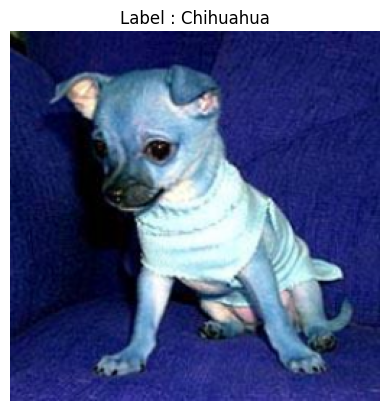

In [ ]:
plot_img_lab(1, "train")

Les `réseaux de neurones convolutifs` (**CNN**) sont une famille de modèles de deep learning adaptés au traitement des données structurées spatialement, comme les images. Contrairement aux `réseaux entièrement connectés` (**MLP**), les CNN exploitent la structure locale des images en utilisant des filtres de convolution qui parcourent l’image afin d’extraire des motifs pertinents.

Un CNN est généralement composé de :
- **Couches de convolution**, qui appliquent des filtres pour extraire des caractéristiques locales. Il est possible d’ajouter du **padding** afin de conserver la taille spatiale de l’image en sortie de convolution et de limiter la perte d’information sur les bords de l’image.
    
- **Couches d’activation**, permettant d’introduire de la non-linéarité.
    
- **Couches de pooling** (max pooling ou average pooling), qui réduisent la dimension spatiale de l’imagen et diminuent le nombre de paramètres.
    
- **Couches entièrement connectées** (Dense), utilisées en fin de réseau pour effectuer la classification. Ces couches sont précédées d’une opération de **flatten**, qui permet d’aplatir les dimensions spatiales afin d’obtenir un vecteur de dimension 1 compatible avec les couches denses.

Dans notre cas, il s’agit d’un problème de `classification multi-classe` (5 classes). Nous utilisons donc la fonction de perte **categorical cross-entropy**, définie par la formule suivante :

$$ Loss = - \sum_{i=1}^{5} y_i \log(f(x_i)) $$
où :
- $y_i$ correspond à la probabilité réelle (encodée en one-hot) de la classe $i$,
- $f(x_i)$ est la probabilité prédite par le modèle pour la classe $i$.

Dans un modèle de **classification multi-classe**, la fonction d’activation utilisée dans la couche de sortie est la fonction **softmax**.  
Cette fonction permet de transformer les sorties du réseau en probabilités, dont la somme est égale à 1.
La fonction softmax est définie par la formule suivante :

$$softmax(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{5} e^{z_j}}$$




Dans nos réseaux de neurones, afin d’améliorer les performances et de limiter le **surapprentissage**, nous utilisons différentes méthodes de `régularisation`.

Parmi les principales techniques utilisées, on retrouve :

- **Dropout** :  
Le dropout consiste à désactiver aléatoirement un certain pourcentage de neurones lors de la phase d’entraînement. Cette technique empêche le réseau de devenir trop dépendant de certaines connexions. Le dropout est utilisé uniquement pendant l’entraînement.


- **Régularisation L1 et L2** :  
Les régularisation L1 et L2 ajoute un terme de pénalisation à la fonction de perte afin de contraindre la valeur des poids du réseau.  
La régularisation **L1** favorise des poids nuls, tandis que la régularisation **L2** limite la croissance excessive des poids et stabilise l’apprentissage.

- **Early stopping** :  
L’early stopping est une méthode qui consiste à arrêter l’entraînement lorsque les performances sur le jeu de validation cessent de s’améliorer. En surveillant une métrique comme la loss de validation, cette technique permet de conserver le modèle à l’état où sa capacité de généralisation est maximale et d’éviter un apprentissage excessif sur les données d’entraînement.

- **Data augmentation** :  
La data augmentation consiste à augmenter artificiellement la taille du jeu de données d’entraînement en appliquant des transformations aux images (rotations, translations, zoom, retournements, etc.). Cette technique permet d’améliorer la capacité de généralisation du modèle et de réduire le surapprentissage.



### **Entrainement d'un petit CNN**

On propose dans un premier temps un modèle avec 3 couches convolutionnelles accompagnées de maxpooling ainsi que qu'une couche dense précédent la couche de sortie, on propose d'utiliser un optimiseur adam dans un premier temps et de réaliser 20 epochs.

In [ ]:
model_cnn_1 = models.Sequential()
model_cnn_1.add(layers.Conv2D(32, (3,3), activation="relu"))
model_cnn_1.add(layers.MaxPooling2D(2,2))

model_cnn_1.add(layers.Conv2D(64, (3,3), activation="relu"))
model_cnn_1.add(layers.MaxPooling2D(2,2))

model_cnn_1.add(layers.Conv2D(128, (3,3), activation="relu"))
model_cnn_1.add(layers.MaxPooling2D(2,2))

model_cnn_1.add(layers.Flatten())
model_cnn_1.add(layers.Dense(64, activation="relu"))
model_cnn_1.add(layers.Dense(5, activation="softmax"))

In [ ]:
model_cnn_1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_1 = model_cnn_1.fit(X_train, y_train , batch_size=32, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2246 - loss: 1.9377 - val_accuracy: 0.2057 - val_loss: 1.5824
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.2674 - loss: 1.5366 - val_accuracy: 0.2624 - val_loss: 1.4801
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.3654 - loss: 1.4109 - val_accuracy: 0.3333 - val_loss: 1.3924
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4973 - loss: 1.2501 - val_accuracy: 0.4043 - val_loss: 1.3276
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5900 - loss: 1.0324 - val_accuracy: 0.4255 - val_loss: 1.3772
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6471 - loss: 0.8629 - val_accuracy: 0.4043 - val_loss: 1.7362
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6827 - loss: 0.8098 - val_accuracy: 0.3972 - val_loss: 1.8775
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7469 - loss: 0.7076 - val_accuracy: 0.3830 - val_loss:

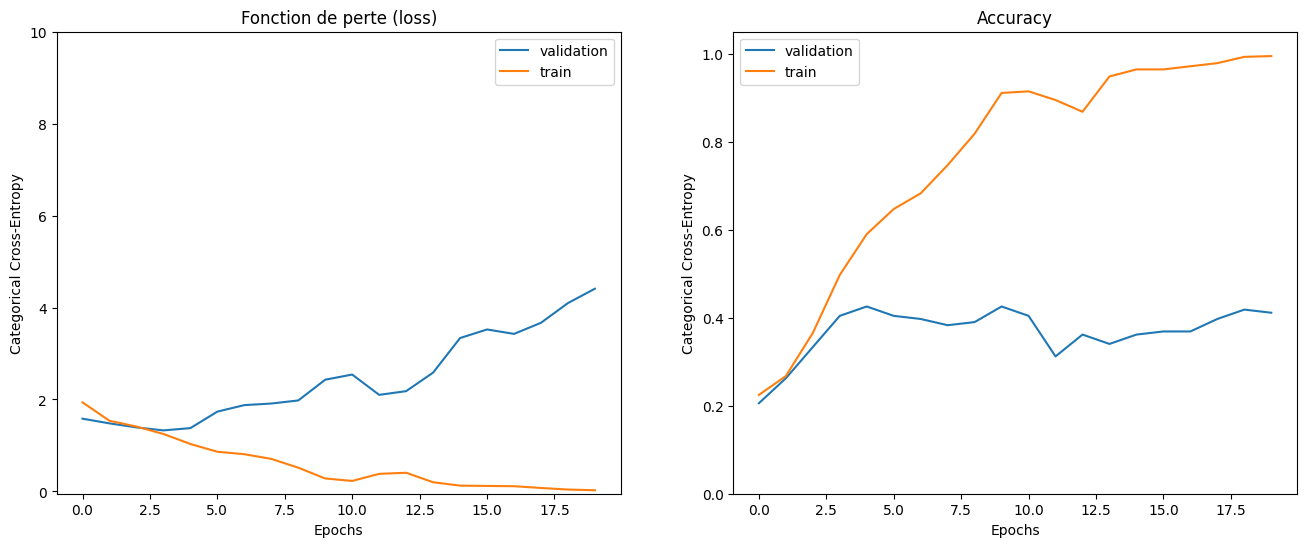

18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 397ms/step - accuracy: 1.0000 - loss: 0.0103
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.3761 - loss: 4.8870
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step


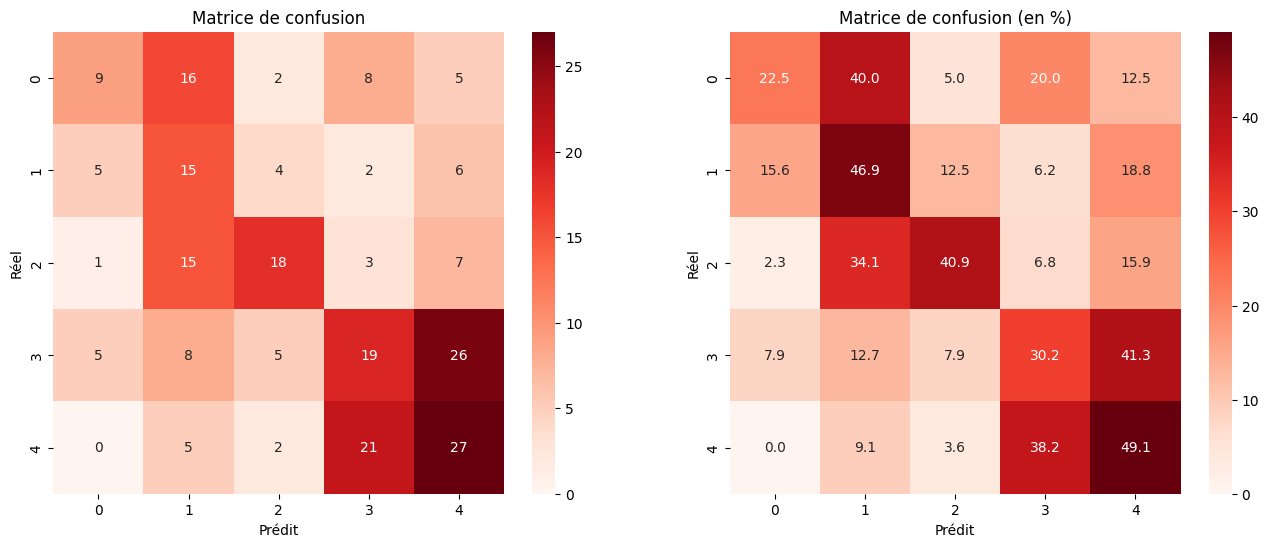

In [ ]:
plot_loss_accuracy(history_1)

model_cnn_1.evaluate(X_train, y_train)
model_cnn_1.evaluate(X_test, y_test)

y_pred_1 = model_cnn_1.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_1)

On obtient une accuracy sur la dernière époque de 0.995 ce qui s'apparente à un bon score cependant en évaluant sur l'échantillon de test on obtient une accuracy à 0.376 et une perte à 4.88, on peut en conclure à du surapprentissage, l'algorithme capte les particularité des images du jeux d'entrainement et ne parvient pas à généraliser. En faisant apparapitre les matrices de confusions on s'aperçoit que que certaines classes se confondent plus que d'autres, en effet la classe 1 est prédite de manière a peu près équivalente en présence d'image des classes 0 1 et 2, de même les classes 3 et 4 semblent également être confondues par le réseau.

In [ ]:
model_cnn_2 = models.Sequential()
model_cnn_2.add(layers.Conv2D(32, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Conv2D(64, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Conv2D(128, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Flatten())
model_cnn_2.add(layers.Dense(64, activation="relu"))
model_cnn_2.add(layers.Dense(5, activation="softmax"))


In [ ]:
model_cnn_2.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history_2 = model_cnn_2.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.2014 - loss: 3.4421 - val_accuracy: 0.2270 - val_loss: 1.6092
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.2139 - loss: 1.6059 - val_accuracy: 0.3191 - val_loss: 1.5967
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.2620 - loss: 1.5964 - val_accuracy: 0.2199 - val_loss: 1.5962
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.3226 - loss: 1.5314 - val_accuracy: 0.2270 - val_loss: 1.5841
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4011 - loss: 1.4266 - val_accuracy: 0.3972 - val_loss: 1.4390
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4314 - loss: 1.3671 - val_accuracy: 0.3191 - val_loss: 1.4201
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4813 - loss: 1.2213 - val_accuracy: 0.3901 - val_loss: 1.3637
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5508 - loss: 1.1370 - val_accuracy: 0.4255 - val_loss:

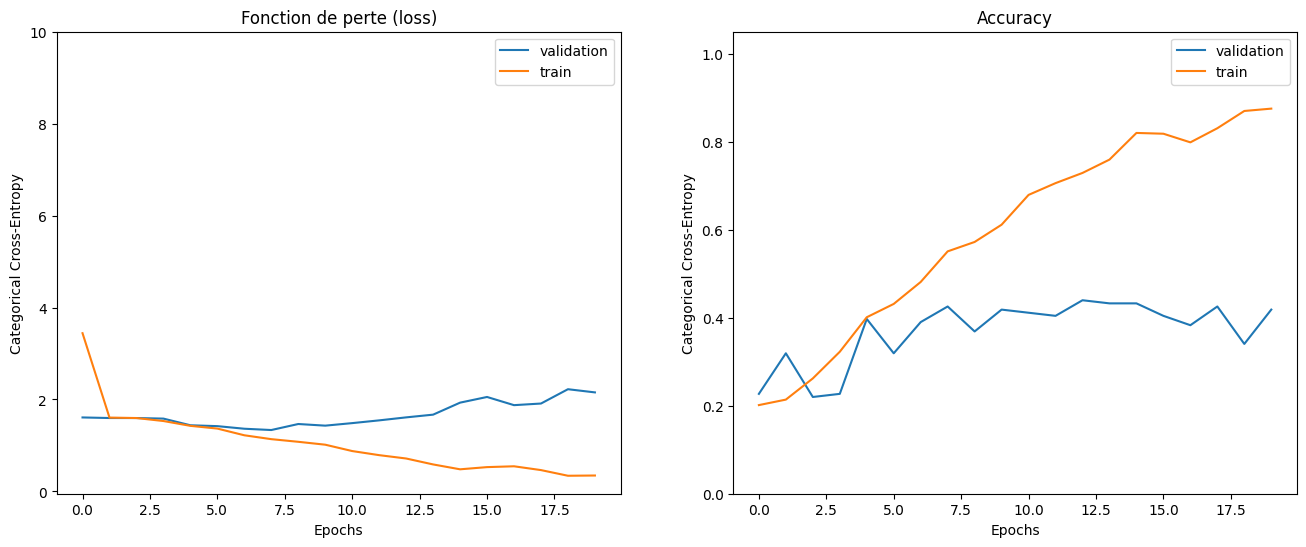

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 346ms/step - accuracy: 0.8859 - loss: 0.3334
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.3504 - loss: 2.7524
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step


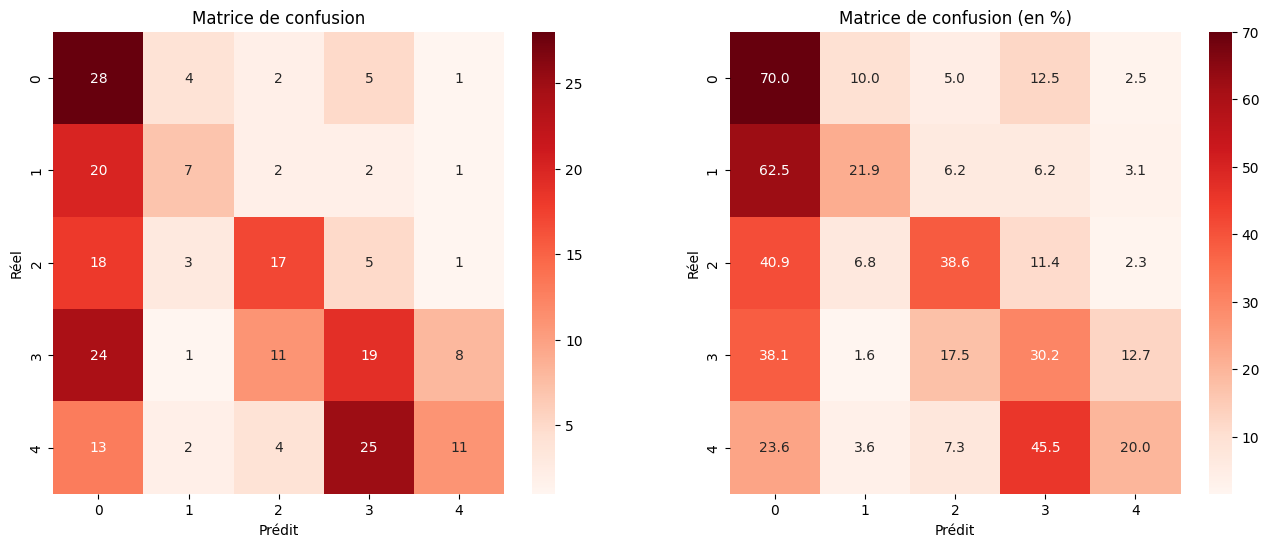

In [ ]:
plot_loss_accuracy(history_2)

model_cnn_2.evaluate(X_train, y_train)
model_cnn_2.evaluate(X_test, y_test)

y_pred_2 = model_cnn_2.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_2)

Même si l’on observe une accuracy relativement élevée pendant l’entraînement (environ 0,89), celle obtenue sur les données de test est nettement plus faible (environ 0,35), ce qui indique un fort sur-apprentissage. La matrice de confusion montre que le modèle reconnaît correctement certaines classes, notamment la classe 0 (70 % de bonnes prédictions) et, dans une moindre mesure, les classes 2 et 3. En revanche, on observe de fortes confusions vers la classe 0, qui est souvent prédite à tort pour les classes 1, 2, 3 et 4, ce qui suggère un biais du modèle en sa faveur. Les classes 1 et 4 sont particulièrement mal discriminées, avec des taux de reconnaissance faibles (environ 22 % et 20 %). Globalement, le modèle peine à séparer clairement les classes entre elles.

In [ ]:
model_cnn_3 = models.Sequential()
model_cnn_3.add(layers.Conv2D(32, (3,3), activation="relu"))
model_cnn_3.add(layers.MaxPooling2D(2,2))
model_cnn_3.add(layers.Dropout(0.5))


model_cnn_3.add(layers.Conv2D(64, (3,3), activation="relu"))
model_cnn_3.add(layers.MaxPooling2D(2,2))
model_cnn_3.add(layers.Dropout(0.5))


model_cnn_3.add(layers.Conv2D(128, (3,3), activation="relu"))
model_cnn_3.add(layers.MaxPooling2D(2,2))
model_cnn_3.add(layers.Dropout(0.5))


model_cnn_3.add(layers.Flatten())
model_cnn_3.add(layers.Dense(64, activation="relu"))
model_cnn_3.add(layers.Dense(5, activation="softmax"))


In [ ]:
model_cnn_3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_3 = model_cnn_3.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1961 - loss: 5.0895 - val_accuracy: 0.1560 - val_loss: 1.6097
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.2157 - loss: 1.6094 - val_accuracy: 0.2553 - val_loss: 1.6091
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.2745 - loss: 1.6087 - val_accuracy: 0.2553 - val_loss: 1.6085
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.2353 - loss: 1.6080 - val_accuracy: 0.2766 - val_loss: 1.6073
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.2246 - loss: 1.6074 - val_accuracy: 0.2979 - val_loss: 1.6065
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2228 - loss: 1.6053 - val_accuracy: 0.2199 - val_loss: 1.6041
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.2406 - loss: 1.6050 - val_accuracy: 0.2624 - val_loss: 1.6054
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2478 - loss: 1.6002 - val_accuracy: 0.2199 - val_loss:

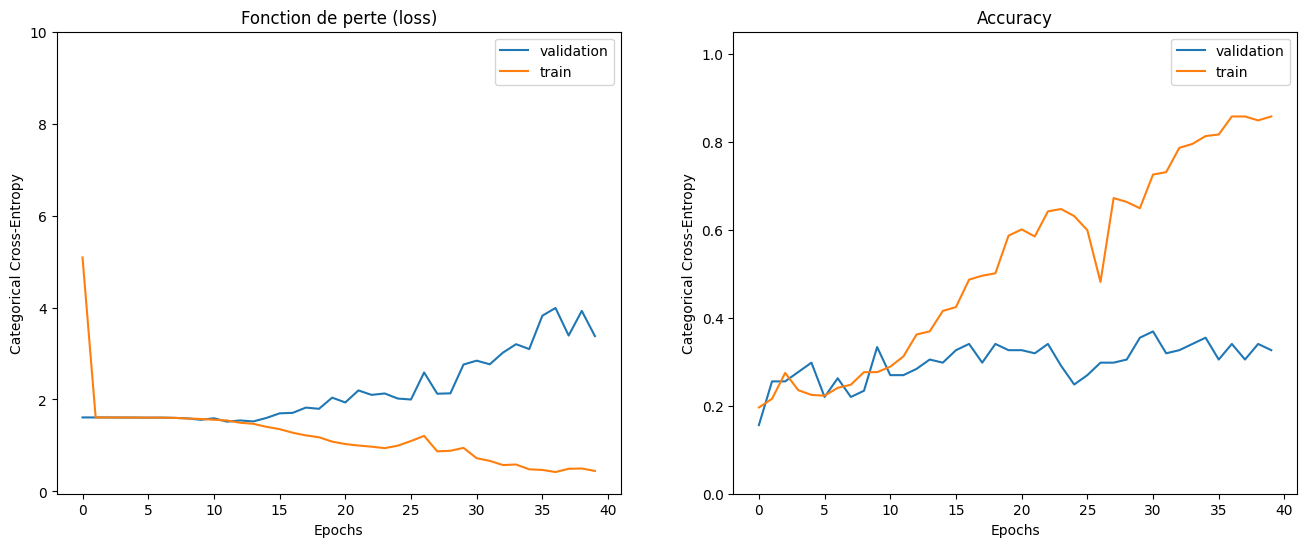

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.9127 - loss: 0.3308
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.3205 - loss: 3.7685
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step


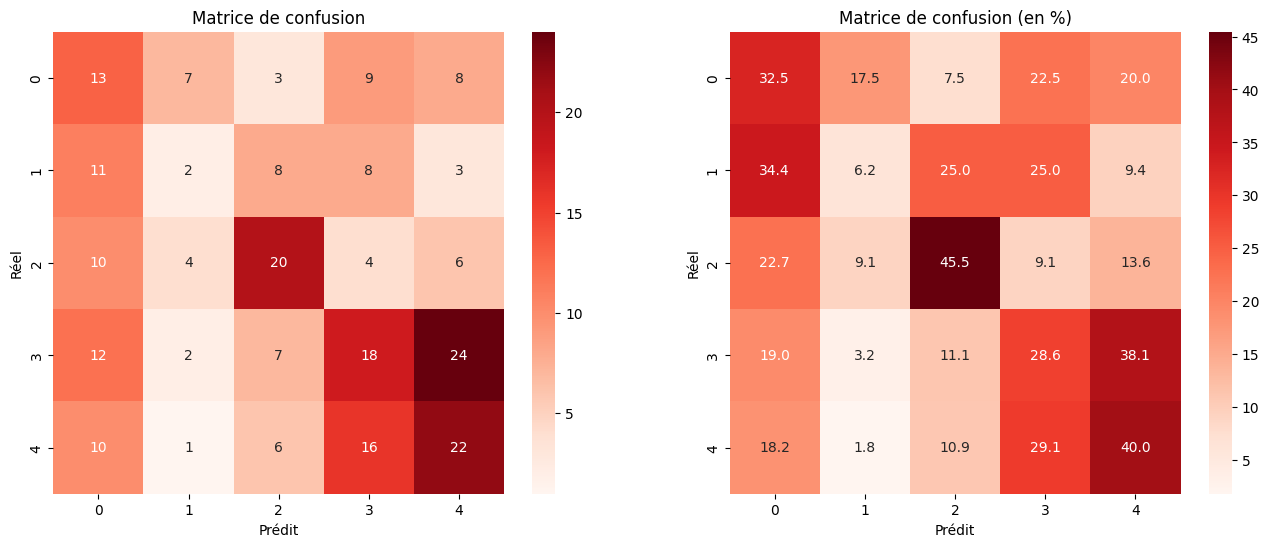

In [ ]:
plot_loss_accuracy(history_3)

model_cnn_3.evaluate(X_train, y_train)
model_cnn_3.evaluate(X_test, y_test)

y_pred_3 = model_cnn_3.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_3)

Les courbes d’apprentissage montrent un sur-apprentissage très marqué. La perte d’entraînement diminue régulièrement tandis que la perte de validation augmente après quelques époques, ce qui indique que le modèle mémorise les données d’entraînement sans améliorer sa capacité de généralisation. Ce constat est confirmé par l’accuracy : elle atteint une valeur élevée sur le jeu d’entraînement (0,91), alors qu’elle reste faible et instable sur le jeu de validation/test (0,32).

La matrice de confusion reflète ce comportement. Les prédictions sont fortement dispersées et plusieurs classes sont massivement confondues entre elles. La classe 2 est la mieux reconnue (45 %), tandis que les classes 1 et 0 présentent des taux de reconnaissance très faibles. On observe également une confusion importante entre les classes 3 et 4, souvent prédites l’une pour l’autre. Globalement, malgré de bonnes performances apparentes à l’entraînement, le modèle ne parvient pas à apprendre des frontières de décision robustes, ce qui suggère la nécessité de régularisation, d’un arrêt anticipé (early stopping), d’un meilleur équilibrage des classes ou d’une révision de l’architecture et des données d’entrée.

In [ ]:
model_cnn_2 = models.Sequential()
model_cnn_2.add(layers.Conv2D(32, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Conv2D(64, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Conv2D(128, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Flatten())
model_cnn_2.add(layers.Dense(64, activation="relu"))
model_cnn_2.add(layers.Dense(5, activation="softmax"))

In [ ]:
model_cnn_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_100 (Conv2D)             │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_102 (Conv2D)             │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     7,372,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,932,876 (56.96 MB)

 Trainable params: 7,466,437 (28.48 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,466,439 (28.48 MB)

In [ ]:
model_cnn_2.compile(optimizer=tf.keras.optimizers.RMSprop(), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_2_op = model_cnn_2.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.2086 - loss: 4.5681 - val_accuracy: 0.2128 - val_loss: 1.6080
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1800 - loss: 1.6074 - val_accuracy: 0.2766 - val_loss: 1.6036
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.2282 - loss: 1.6105 - val_accuracy: 0.1844 - val_loss: 1.6065
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.1979 - loss: 1.6069 - val_accuracy: 0.2270 - val_loss: 1.6035
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.2709 - loss: 1.6301 - val_accuracy: 0.3688 - val_loss: 1.5517
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3155 - loss: 1.5715 - val_accuracy: 0.2766 - val_loss: 1.6067
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.3904 - loss: 1.4755 - val_accuracy: 0.3262 - val_loss: 1.5041
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4439 - loss: 1.3725 - val_accuracy: 0.3759 - val_loss:

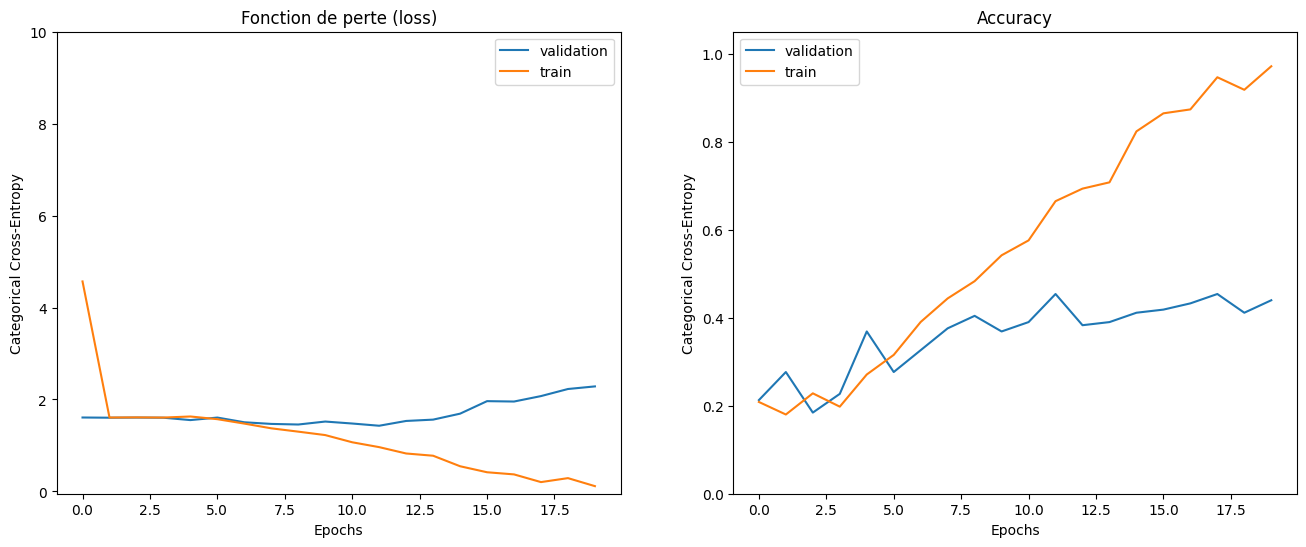

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.9911 - loss: 0.0595
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.4017 - loss: 2.7314
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step


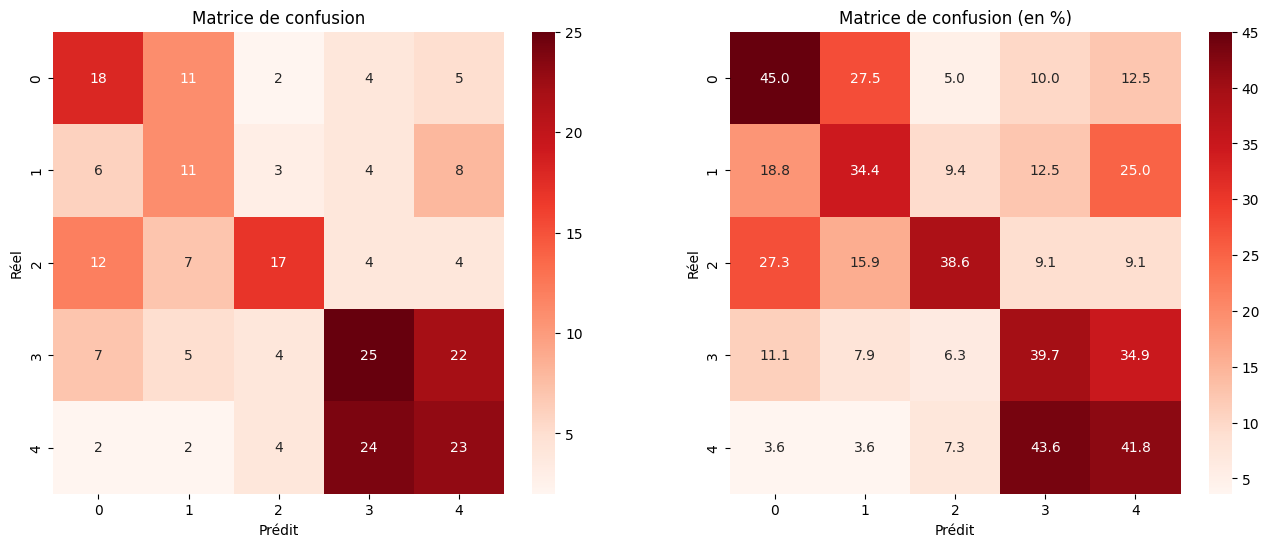

In [ ]:
plot_loss_accuracy(history_2_op)

model_cnn_2.evaluate(X_train, y_train)
model_cnn_2.evaluate(X_test, y_test)

y_pred_2 = model_cnn_2.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_2)

On observe ici une amélioration globale, même si le sur-apprentissage reste présent. Les courbes montrent que la perte d’entraînement chute fortement et que l’accuracy atteint presque 1, ce qui indique que le modèle apprend très bien les données d’entraînement. Côté validation, la loss augmente plus modérément qu’auparavant et l’accuracy progresse jusqu’à environ 0,40, ce qui représente un gain notable par rapport aux essais précédents, bien que l’écart train/validation reste important.

La matrice de confusion confirme cette amélioration. Les prédictions sont davantage concentrées sur la diagonale, en particulier pour les classes 2, 3 et 4, qui atteignent des taux de reconnaissance proches de 39–45 %. Les confusions sont toujours présentes, notamment entre les classes 3 et 4, ainsi qu’entre 0 et 1, mais elles sont moins diffuses qu’avant.

C'est sur ce modèle que l'on va mettre en place de l'augmentation de données

### **Petit CNN avec Augmentation**

In [ ]:
train_data_gen = ImageDataGenerator(rotation_range=15,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.1,
                                   zoom_range=0.1,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

train_generator_m2 = train_data_gen.flow(X_train, y_train, batch_size=32, shuffle=True)

In [ ]:
model_cnn_2 = models.Sequential()
model_cnn_2.add(layers.Conv2D(32, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Conv2D(64, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Conv2D(128, (3,3), activation="relu"))
model_cnn_2.add(layers.MaxPooling2D(2,2))
model_cnn_2.add(layers.Dropout(0.25))


model_cnn_2.add(layers.Flatten())
model_cnn_2.add(layers.Dense(64, activation="relu"))
model_cnn_2.add(layers.Dense(5, activation="softmax"))

In [ ]:
model_cnn_2.compile(optimizer=tf.keras.optimizers.RMSprop(), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_2_aug = model_cnn_2.fit(train_generator_m2, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.4349 - loss: 1.3199 - val_accuracy: 0.4043 - val_loss: 1.3661
Epoch 2/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.4421 - loss: 1.3138 - val_accuracy: 0.4397 - val_loss: 1.3135
Epoch 3/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.4171 - loss: 1.3094 - val_accuracy: 0.4397 - val_loss: 1.3454
Epoch 4/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.4189 - loss: 1.3128 - val_accuracy: 0.4255 - val_loss: 1.3350
Epoch 5/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.4545 - loss: 1.2853 - val_accuracy: 0.4610 - val_loss: 1.3378
Epoch 6/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4670 - loss: 1.2575 - val_accuracy: 0.4539 - val_loss: 1.3610
Epoch 7/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4545 - loss: 1.2720 - val_accuracy: 0.3901 - val_loss: 1.3903
Epoch 8/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4688 - loss: 1.2333 - val_accuracy: 0.4326 - val_loss: 1.2993
Epoch 9/

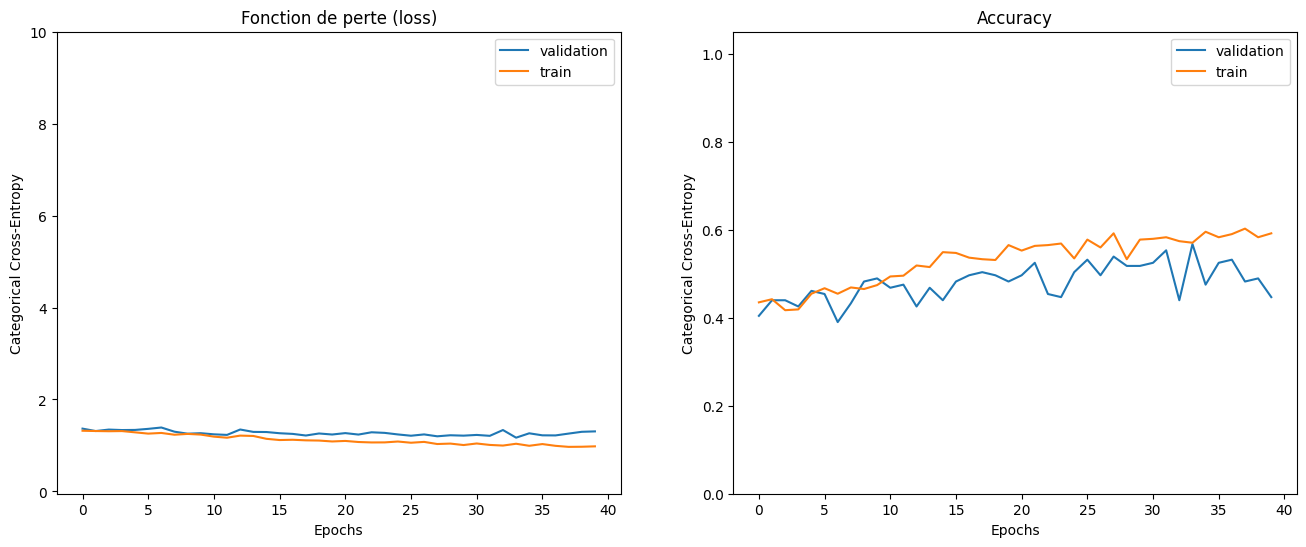

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 354ms/step - accuracy: 0.6185 - loss: 0.9441
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 359ms/step - accuracy: 0.3974 - loss: 1.4708
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 395ms/step


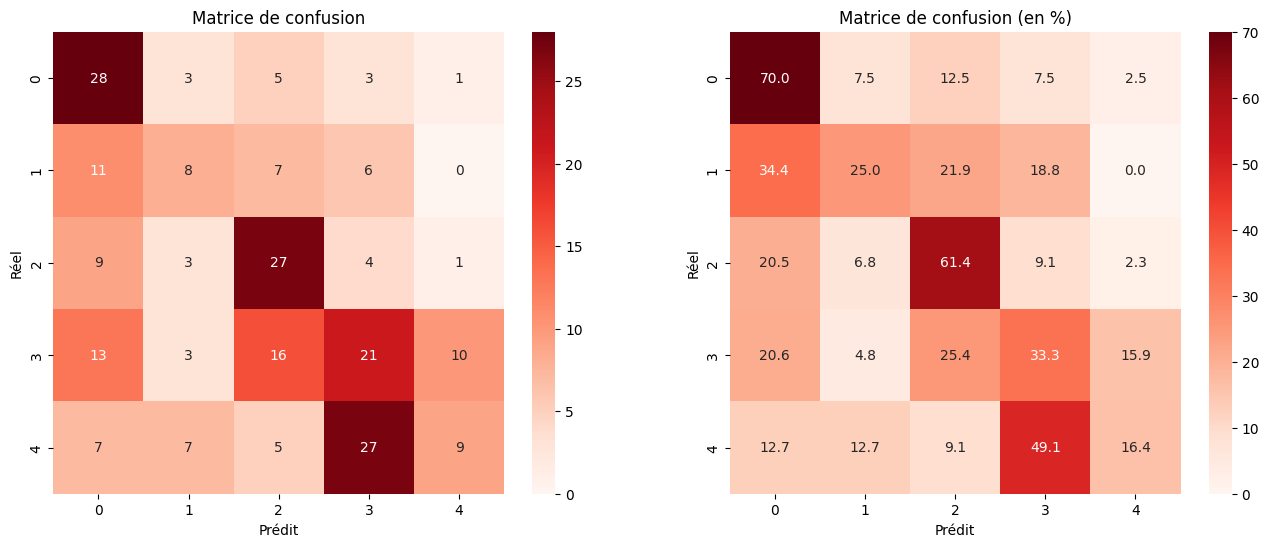

In [ ]:
plot_loss_accuracy(history_2_aug)

model_cnn_2.evaluate(X_train, y_train)
model_cnn_2.evaluate(X_test, y_test)

y_pred_2 = model_cnn_2.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_2)

On s'aperçoit que ici que l'accuracy ne s'améliore que très faiblement epoche après epoche, la différences entre l'accuracy du train et de la validation est en revanche globalement faible tout comme en loss, ce rapprochement est visible sur les courbes qui sont très proche l'une de l'autre. La matrice de confusion montre qu'il y encore de l'instabilité dans les prédictions, on observe notamment que la classe 4 est le plus souvent prédite comme étant la 3 et que la classe 3 elle, n'est prédite correctement que dans 33% des cas.

### **Comparaison du modèle avec et sans augmentation**

**Résumer des résultats :**

| Métrique | Sans Augmentation | Avec Augmentation |
|----------|-------------------|-------------------|
| **Accuracy Train** | 99.1% | 61.8% |
| **Accuracy Test** | 43.8% | 44.6% |
| **Loss Train** | 0.06 | 0.94 |
| **Loss Test** | 2.73 | 1.47 |
| **Écart Train-Test** | 55.3% | 17.2% |
| **Nombre d'epochs** | 20 | 50 |

L’ajout de la data augmentation réduit nettement le sur-apprentissage. Sans augmentation, le modèle atteint une accuracy d’entraînement très élevée (99,1 %) avec une loss quasi nulle, mais cette performance ne se transfère pas au test, ce qui se traduit par un écart train-test très important (55,3 %). Cela indique que le modèle mémorise les données plutôt qu’il n’apprend des caractéristiques généralisables.

Avec la data augmentation, l’accuracy d’entraînement chute à 61,8 % et la loss augmente, ce qui est attendu : les données augmentées rendent la tâche plus difficile et empêchent le modèle de sur-adapter. En contrepartie, la performance sur le jeu de test s’améliore légèrement (44,6 % contre 43,8 %) et, surtout, la loss de test diminue fortement (1,47 contre 2,73), signe de prédictions plus stables et moins confiantes à tort.

L’élément le plus révélateur est la forte réduction de l’écart train-test (17,2 % contre 55,3 %), qui montre une bien meilleure capacité de généralisation. Le nombre d’epochs plus élevé avec augmentation est cohérent, car le modèle a besoin de plus d’itérations pour converger face à une plus grande variabilité des données.

### **Utilisation du transfert learning en mode feature extraction**

Le `transfert learning` consiste à réutiliser un modèle pré-entraîné sur un grand jeu de données afin de résoudre une nouvelle tâche de classification. On va tout d'abord utilisé le transfert learning en mode **feature extraction**, les couches convolutives du modèle pré-entraîné sont gelées, c’est-à-dire que leurs poids ne sont pas modifiés lors de l’entraînement.

Ces couches sont utilisées comme extracteurs de caractéristiques, tandis que seules les couches finales (couches dense ajoutées au modèle) sont entraînées sur le nouveau jeu de données. Cette approche est particulièrement efficace lorsque le jeu de données cible est de taille limitée, car elle permet de bénéficier de représentations déjà apprises tout en réduisant le temps d’entraînement et le risque de surapprentissage.

***Modèles pré-entraîné : InceptionV3***

Nous avons utilisés le modèle pré-entraîné `InceptionV3`, qui a démontré de très bonnes et meilleurs performances par rapport aux autres modèle essayer.

**InceptionV3** est une architecture plus complexe. Elle repose sur des blocs Inception, qui appliquent plusieurs filtres de tailles différentes (1 $\times$ 1, 3 $\times$ 3) en parallèle sur la même entrée, puis concatènent les résultats. Cette approche permet au réseau de capturer des caractéristiques à plusieurs échelles tout en limitant le nombre de paramètres grâce à l’usage de convolutions 1 $\times$ 1 (souvent mis en entré et sortie de bloc) pour réduire la dimension.
Ce réseau de neurones à une profondeur de 48 couches

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
base_model2 = InceptionV3(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
base_model2.trainable = False

On commence par évaluer réseau simple sans ajout de régularisation, on utilise juste l'early stopping afin de selection un nombre d'epoque raisonnable. Puis on trace les courbes d'accuracy et de train de l'entrainement.

In [ ]:
base_model2.trainable = False

model_tf_learn_02 = models.Sequential()
model_tf_learn_02.add(base_model2)
model_tf_learn_02.add(layers.Flatten())
model_tf_learn_02.add(layers.Dense(64, activation='relu'))
model_tf_learn_02.add(layers.Dense(5, activation='softmax'))

model_tf_learn_02.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_tf_learn_02 = model_tf_learn_02.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6773 - loss: 2.8414 - val_accuracy: 0.9291 - val_loss: 1.5505
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.9802 - loss: 0.3188 - val_accuracy: 0.9149 - val_loss: 1.2080
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9646 - loss: 0.7228 - val_accuracy: 0.9149 - val_loss: 1.6812
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9573 - loss: 0.3983 - val_accuracy: 0.9220 - val_loss: 2.0890
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9923 - loss: 0.1346 - val_accuracy: 0.9220 - val_loss: 1.2078
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 1.0000 - loss: 7.7555e-07 - val_accuracy: 0.9362 - val_loss: 1.8430
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 1.0000 - loss: 2.1673e-05 - val_accuracy: 0.9291 - val_loss: 1.9800
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 1.0000 - loss: 1.7278e-04 - val_ac

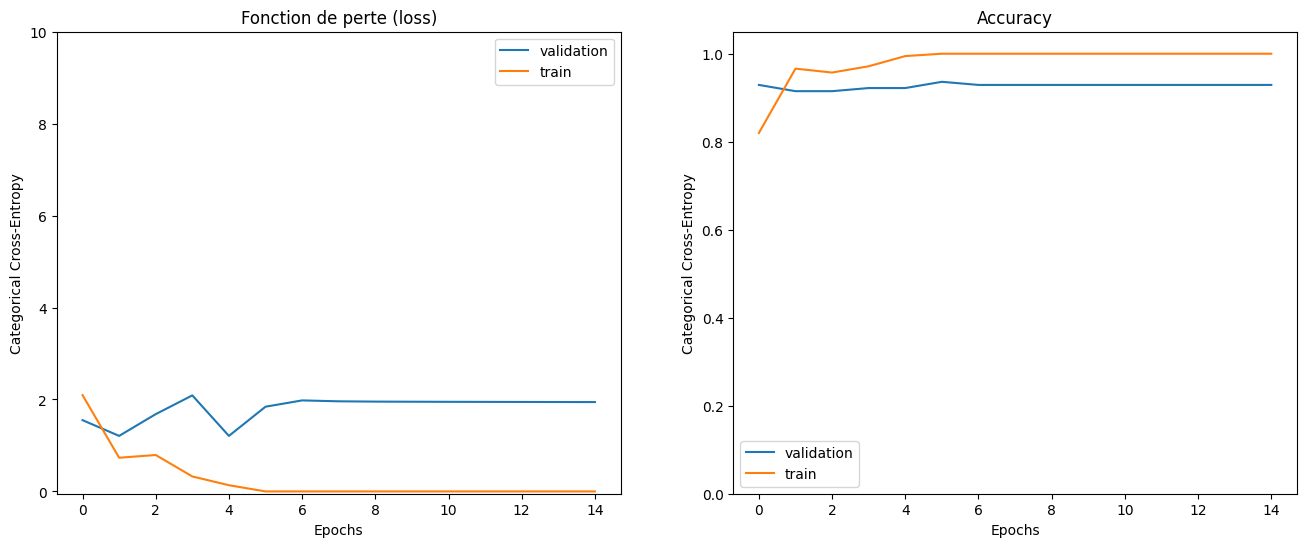

In [ ]:
plot_loss_accuracy(history_tf_learn_02)

In [ ]:
model_tf_learn_02.evaluate(X_train, y_train)
model_tf_learn_02.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step - accuracy: 1.0000 - loss: 3.5016e-06
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 632ms/step - accuracy: 0.9306 - loss: 1.8666


[1.5207127332687378, 0.94017094373703]

On observe sur les courbes d’apprentissage un léger sur-apprentissage, la courbe de validation s'éloigne légerement de celle du train pendant l’entraînement.
Cependant, les performances sur l’échantillon de test sont bonnes (93% contre 100% sur le train au global), ce qui confirme que le modèle généralise correctement malgré ce léger sur-apprentissage.

On regarde ensuite la matrice de confusion des prédiction faites sur X_test.

8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


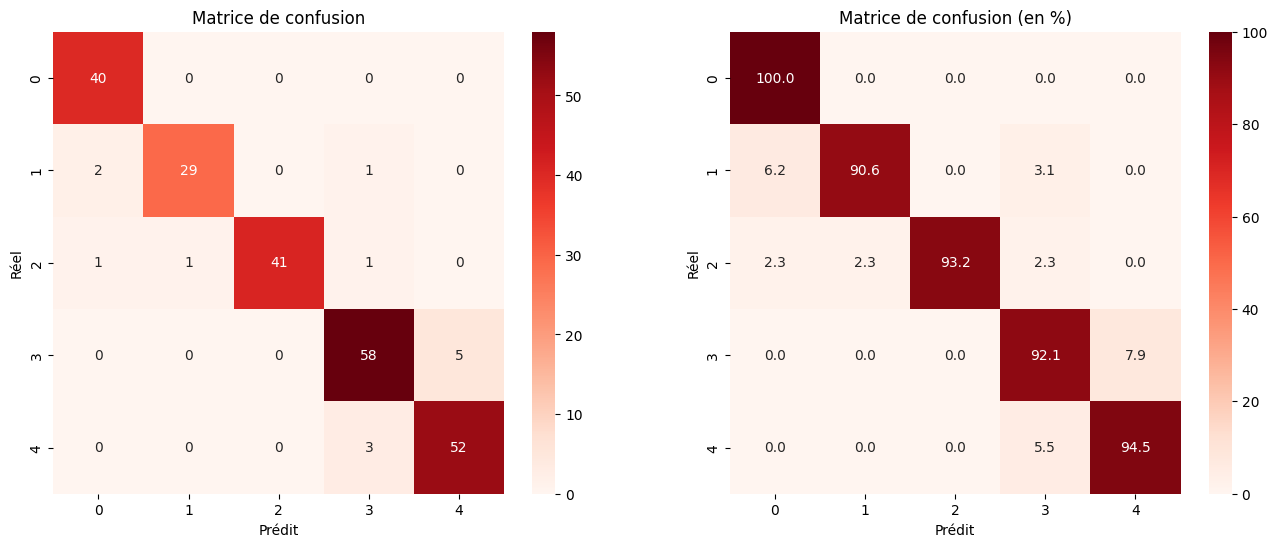

In [ ]:
y_pred_proba_02 = model_tf_learn_02.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_proba_02)

La matrice de confusion confirme que les classes sont bien séparées, avec seulement quelques confusions, principalement la classe 1 qui est souvent catégorisée comme appartenant à la classe 0 et la classe 3 souvent prédite comme étant de la classe 4.
Dans l’ensemble le modèle généralise bien et reconnaît correctement la majorité des races de chiens présentes sur les images.
Nous chercherons toutefois à améliorer ce réseau afin de réduire le sur-apprentissage.

Nous ajoutons maintenant un dropout de 0.5 afin de réduire le léger surapprentissage observé. La taille du batch est également augmenté a 64.

In [ ]:
base_model2.trainable = False

model_tf_learn2 = models.Sequential()
model_tf_learn2.add(base_model2)
model_tf_learn2.add(layers.Flatten())
model_tf_learn2.add(layers.Dense(64, activation='relu'))
model_tf_learn2.add(layers.Dropout(0.5))
model_tf_learn2.add(layers.Dense(5, activation='softmax'))

In [ ]:
model_tf_learn2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_tf_learn2 = model_tf_learn2.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.4844 - loss: 4.9870 - val_accuracy: 0.9504 - val_loss: 0.4075
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.8831 - loss: 0.6152 - val_accuracy: 0.9291 - val_loss: 0.3269
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.8643 - loss: 0.4690 - val_accuracy: 0.9291 - val_loss: 0.3123
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.8851 - loss: 0.2962 - val_accuracy: 0.9645 - val_loss: 0.2126
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.8927 - loss: 0.3148 - val_accuracy: 0.9504 - val_loss: 0.2043
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.8963 - loss: 0.3852 - val_accuracy: 0.9433 - val_loss: 0.2059
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.9212 - loss: 0.2519 - val_accuracy: 0.9433 - val_loss: 0.2423
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.9138 - loss: 0.2423 - val_accuracy: 0.9362 - val_loss: 0

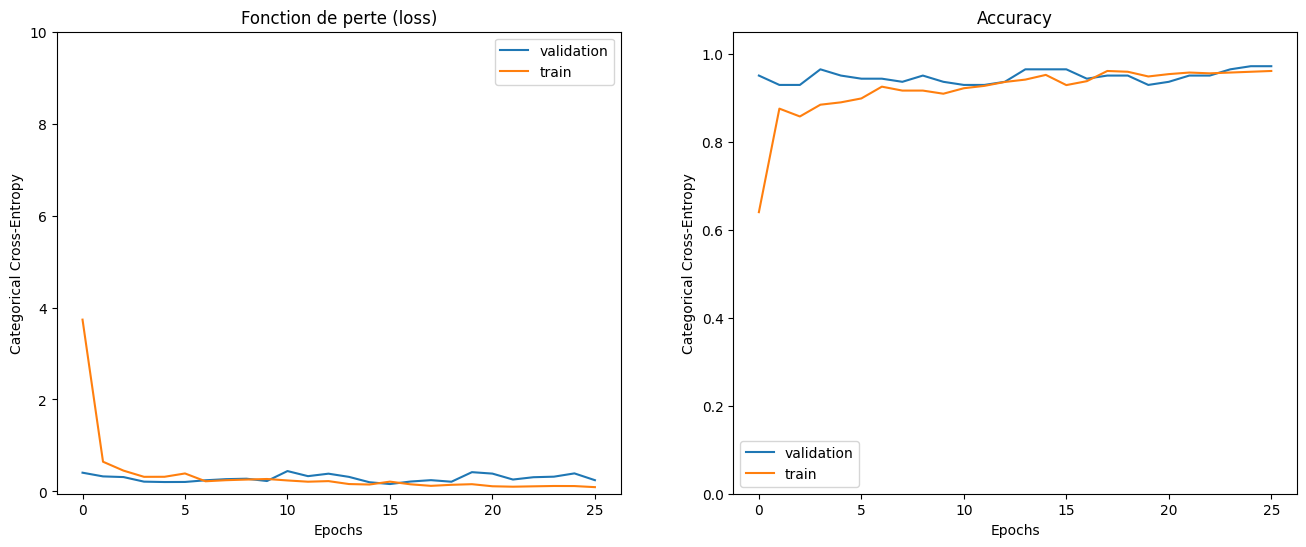

In [ ]:
plot_loss_accuracy(history_tf_learn2)

In [ ]:
model_tf_learn2.evaluate(X_train, y_train)
model_tf_learn2.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 298ms/step - accuracy: 0.9977 - loss: 0.0116
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 611ms/step - accuracy: 0.9411 - loss: 0.6047


[0.6140477061271667, 0.9487179517745972]

On remarque que le sur-apprentissage a été diminué, d’une part en observant les courbes de loss et d’accuracy, qui se rapprochent visuellement, et d’autre part en comparant les performances globales sur les jeux d’entraînement et de test. Sur le jeu d’entraînement, l’accuracy diminue très légèrement tandis que sur le jeu de test elle augmente de plus de 1%. La loss suit le même comportement, on obtient une loss d’environ 0.6 sur le test contre 0.012 sur le train.

8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 986ms/step


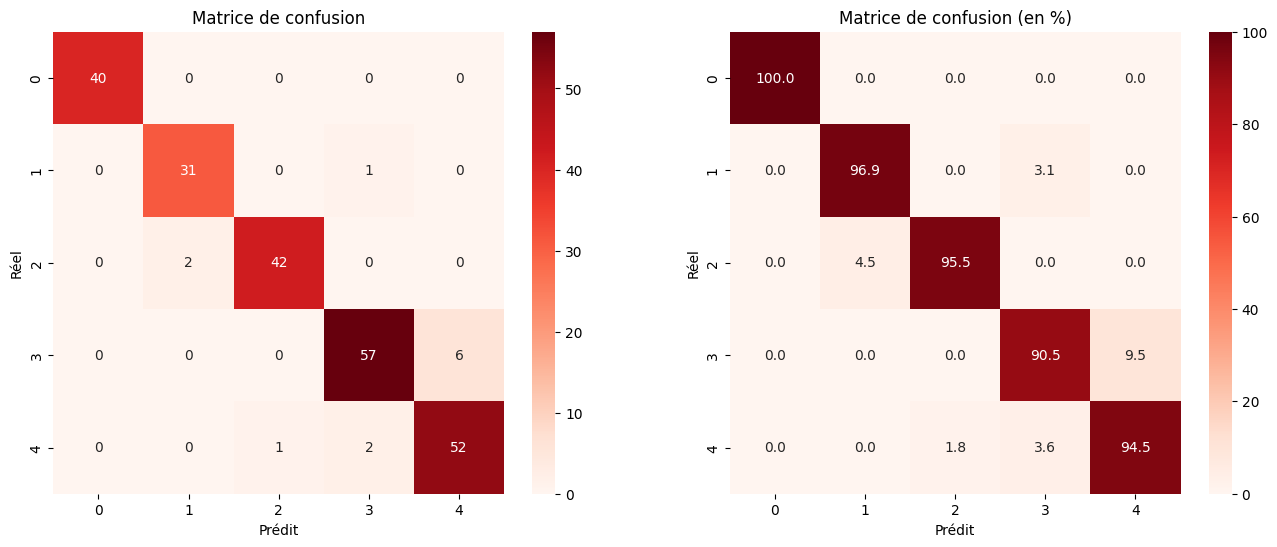

In [ ]:
y_pred_proba2 = model_tf_learn2.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_proba2)

La matrice de confusion confirme que le modèle généralise bien, il reconnaît correctement la majorité des races de chien, le pourcentage de bonne prédiction a largement augmenter pour la classe 1, mais la classe 3 est encore souvent prédites comme étant de la classe 4.

Nous allons donc utilisé la data augmentation afin d’augmenter artificiellement le jeu d’entraînement, d’améliorer les valeurs des métriques et de faire disparaître le sur-apprentissage même si les résultats sont déjà très satisfaisants. Le modèle apprend correctement et généralise bien.

### **Transfert learning avec data augmentation**

Le code suivant crée un générateur de données augmentées pour l’entraînement, appliquant rotations, translations, zooms, cisaillements et flips horizontaux au images déja existantes.
Il permet de diversifier les images de X_train.

In [ ]:
train_datagen = ImageDataGenerator(rotation_range=15,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.1,
                                   zoom_range=0.1,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

train_generator = train_datagen.flow(X_train, y_train, batch_size=64, shuffle=True)

On utilise le dernier modèle de la partie sans data augmentation :

In [ ]:
base_model2.trainable = False

model_tf_learn_aug2 = models.Sequential()
model_tf_learn_aug2.add(base_model2)
model_tf_learn_aug2.add(layers.Flatten())
model_tf_learn_aug2.add(layers.Dense(64, activation='relu'))
model_tf_learn_aug2.add(layers.Dropout(0.5))
model_tf_learn_aug2.add(layers.Dense(5, activation='softmax'))

model_tf_learn_aug2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_tf_learn_aug2 = model_tf_learn_aug2.fit(train_generator, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5603 - loss: 3.3361 - val_accuracy: 0.9504 - val_loss: 0.4924
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 898ms/step - accuracy: 0.8731 - loss: 0.5717 - val_accuracy: 0.9362 - val_loss: 0.1238
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 910ms/step - accuracy: 0.8390 - loss: 0.4766 - val_accuracy: 0.9220 - val_loss: 0.2013
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8522 - loss: 0.3736 - val_accuracy: 0.9362 - val_loss: 0.1804
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 864ms/step - accuracy: 0.8737 - loss: 0.3130 - val_accuracy: 0.9645 - val_loss: 0.2464
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 950ms/step - accuracy: 0.9209 - loss: 0.2960 - val_accuracy: 0.9787 - val_loss: 0.1695
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8993 - loss: 0.3231 - val_accuracy: 0.9433 - val_loss: 0.1562
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 901ms/step - accuracy: 0.8794 - loss: 0.2917 - val_accuracy: 0.9291 - val_loss: 0.2466

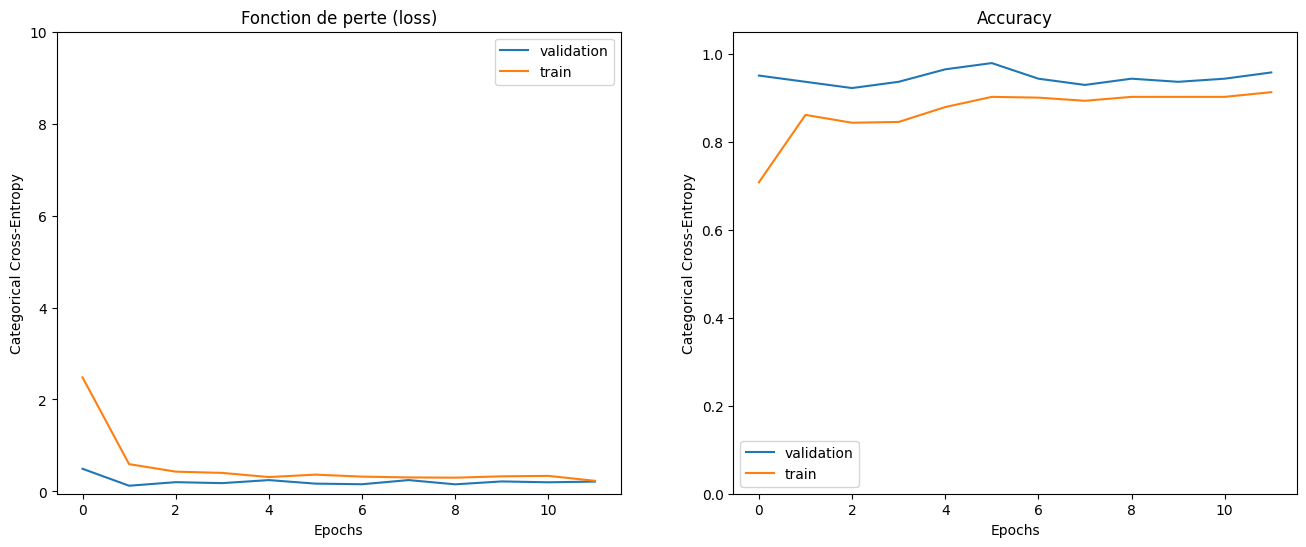

In [ ]:
plot_loss_accuracy(history_tf_learn_aug2)

In [ ]:
model_tf_learn_aug2.evaluate(X_train, y_train)
model_tf_learn_aug2.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 316ms/step - accuracy: 0.9596 - loss: 0.1041
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 730ms/step - accuracy: 0.9324 - loss: 0.3232


[0.3071252405643463, 0.9316239356994629]

Les courbes d’apprentissage restent proches, ce qui est un très bon signe. La loss est faible et l’accuracy élevée, aussi bien sur le train que sur le test. Avec la data augmentation, le modèle atteint 95.9% d’accuracy sur le train et 93.2% sur le test en seulement 12 époques, ce qui montre un apprentissage stable, peu de sur-apprentissage et une bonne capacité de généralisation.

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


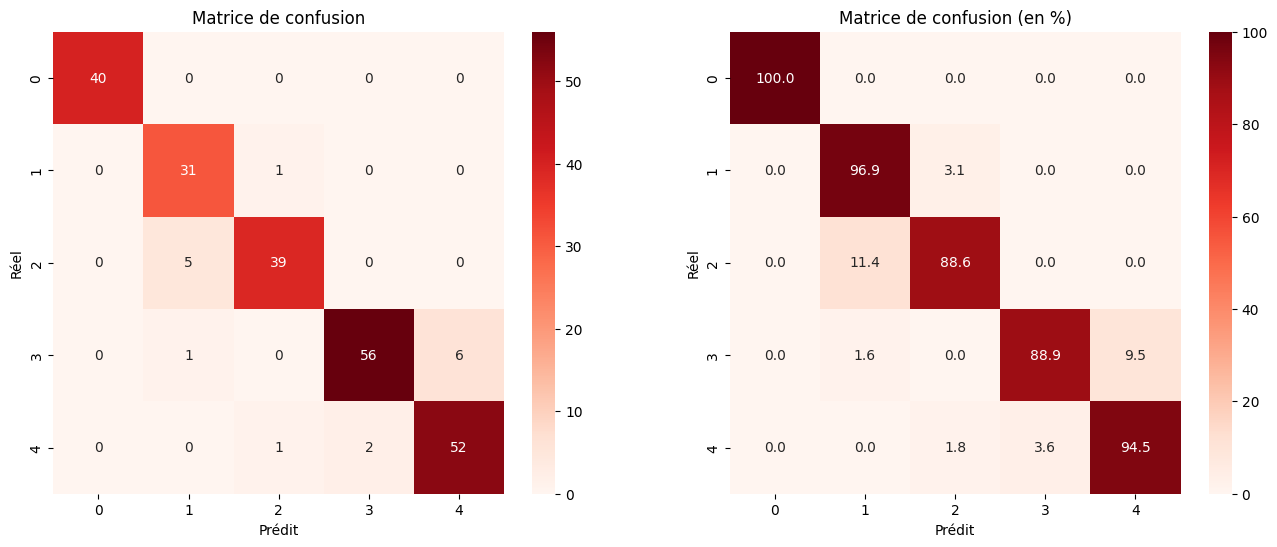

In [ ]:
y_pred_proba_aug2 = model_tf_learn_aug2.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_proba_aug2)

Pour la matrice de confusion, on observe toujours de bonnes prédictions avec un taux de réussite compris entre 88% et 100% selon les classes. La seule dégradation visible par rapport à la matrice sans data augmentation concerne la classe 2, qui est désormais plus souvent prédite comme appartenant à la classe 1 ce qui n’était pas le cas avant.

Cela peut s’expliquer par le fait que les transformations appliquées lors de la data augmentation modifient certaines images de la classe 2, rendant leurs caractéristiques visuelles plus proches de celles de la classe 1.

### **Comparaison avec et sans augmentation**

**Résumer des résultats :**

| Métrique | Sans Augmentation | Avec Augmentation |
|----------|-------------------|-------------------|
| **Accuracy Train** | 99.8% | 95.9% |
| **Accuracy Test** | 94.1% | 93.2% |
| **Loss Train** | 0.012 | 0.104 |
| **Loss Test** | 0.605 | 0.323 |
| **Écart Train-Test** | 5.7% | 2.7% |
| **Nombre d'epochs** | 26 | 12 |

**Sans data augmentation**, le modèle atteint une accuracy très élevée de 99.8% sur le train, mais seulement 94.1% sur le test. L'écart est de 5 points environ et la loss test importante (0.605) révèlent un surapprentissage significatif, le modèle mémorise les données d'entraînement sans très bien généraliser.

**Avec data augmentation**, l'accuracy train diminue à 95.9%, mais le test reste stable à 93.2%. Plus important encore, la loss test est divisée par deux (0.307 -> 0.605) et l'écart train-test est réduit à 2.7%. L'apprentissage converge également plus rapidement (12 epochs au lieu de 26).

On peut donc dire que l'augmentation de données améliore significativement la robustesse et la capacité de généralisation du modèle. Bien que l'accuracy test baisse légèrement.

### **Fine tuning**

Le `fine-tuning` est une extension du transfert learning. Après une phase de feature extraction, on peut choisir de débloquer certaines couches du modèle pré-entraîné afin de les réentraîner sur le nouveau jeu de données.

Cette approche permet au modèle d’adapter plus finement ses représentations aux caractéristiques spécifiques de la nouvelle tâche. Pour éviter de dégrader les poids déjà appris, le fine-tuning est généralement effectué avec un **taux d’apprentissage faible** et de manière progressive, en débloquant d’abord les couches supérieures du réseau.

Après plusieurs essais, nous avons décidé de dégeler les 3 dernières couches du modèle pré-entraîné.

In [ ]:
model_tf_learn_tunning = models.Sequential()
model_tf_learn_tunning.add(base_model2)
model_tf_learn_tunning.add(layers.Flatten())
model_tf_learn_tunning.add(layers.Dense(64, activation='relu'))
model_tf_learn_tunning.add(layers.Dropout(0.5))
model_tf_learn_tunning.add(layers.Dense(5, activation='softmax'))

base_model2.trainable = True
for layer in base_model2.layers[:-3]:
    layer.trainable = False

# Affichage des couches trainable
print("Couches dégelées :")
for i, layer in enumerate(model_tf_learn_tunning.layers[0].layers):
    if layer.trainable:
        print(i, layer.name)



Couches dégelées :
308 concatenate_3
309 activation_187
310 mixed10


Le taux d’apprentissage est fixé à une valeur très faible lors du fine-tuning, car le modèle utilise des poids déjà pré-entraînés et afin de ne pas dégrader les représentations apprises ou de conduire à du sur-apprentissage, il est important d’ajuster progressivement le modèle.

De plus, le paramètre `patience` de l’early stopping a été réglé sur une valeur basse, 3 ici car avec le fine-tuning, le nombre d’époques nécessaires à la convergence est généralement bas, les poids étant déjà proches d’un optimum.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model_tf_learn_tunning.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_tunning = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_tf_learn_tunning = model_tf_learn_tunning.fit(train_generator, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stop_tunning])

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.2655 - loss: 2.1988 - val_accuracy: 0.7092 - val_loss: 0.9580
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5681 - loss: 1.1116 - val_accuracy: 0.8723 - val_loss: 0.5349
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7972 - loss: 0.6750 - val_accuracy: 0.8865 - val_loss: 0.3221
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8631 - loss: 0.4891 - val_accuracy: 0.9362 - val_loss: 0.2227
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8767 - loss: 0.3679 - val_accuracy: 0.9362 - val_loss: 0.1933
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9136 - loss: 0.3143 - val_accuracy: 0.9362 - val_loss: 0.1620
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9287 - loss: 0.2054 - val_accuracy: 0.9433 - val_loss: 0.1385
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9302 - loss: 0.2184 - val_accuracy: 0.9433 - val_loss: 0.1263
Epoch 9/5

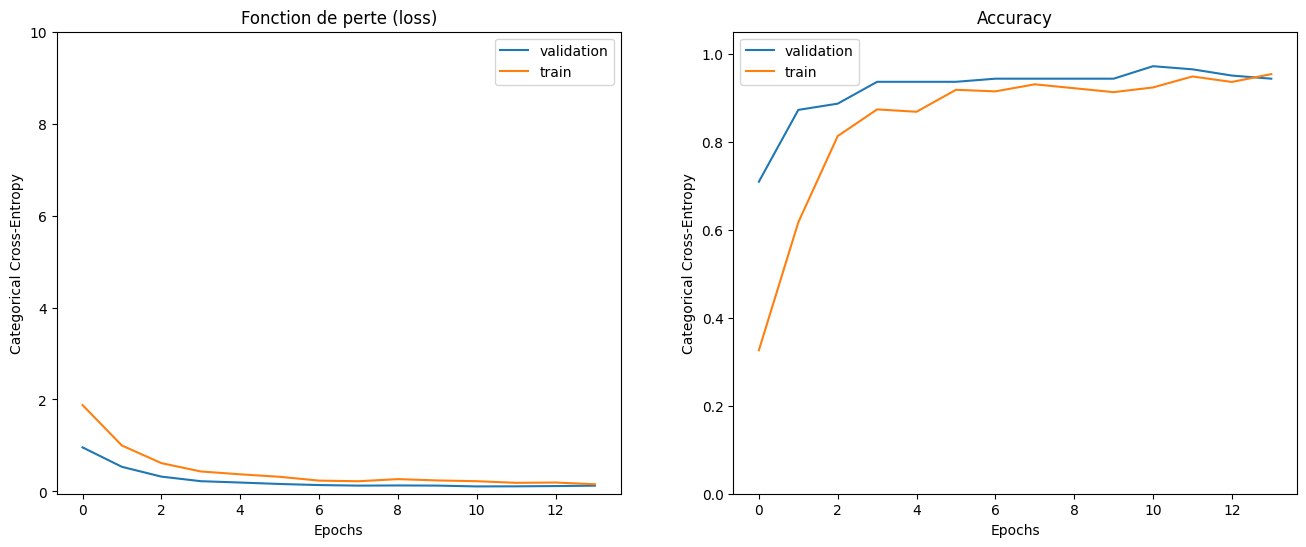

In [ ]:
plot_loss_accuracy(history_tf_learn_tunning)

On observe déjà que le sur-apprentissage n’est plus présent. Les courbes de perte (loss) et de précision (accuracy) sur l’ensemble d’entraînement et sur l’échantillon de validation sont stables et très proches les unes des autres.

Nous allons maintenant évaluer le modèle sur l’échantillon de test afin de confirmer ces observations et mesurer sa capacité de généralisation sur des données jamais vues.

In [ ]:
model_tf_learn_tunning.evaluate(X_train, y_train)
model_tf_learn_tunning.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 382ms/step - accuracy: 0.9794 - loss: 0.0826
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 832ms/step - accuracy: 0.9755 - loss: 0.0898


[0.13142678141593933, 0.9615384340286255]

Le modèle montre d’excellentes performances, il atteint une précision de 97,94 % sur l’ensemble d’entraînement et de 97,55 % sur l’échantillon de test, ce qui montre qu’il généralise très bien et qu’il n’y a pas de sur-apprentissage.

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


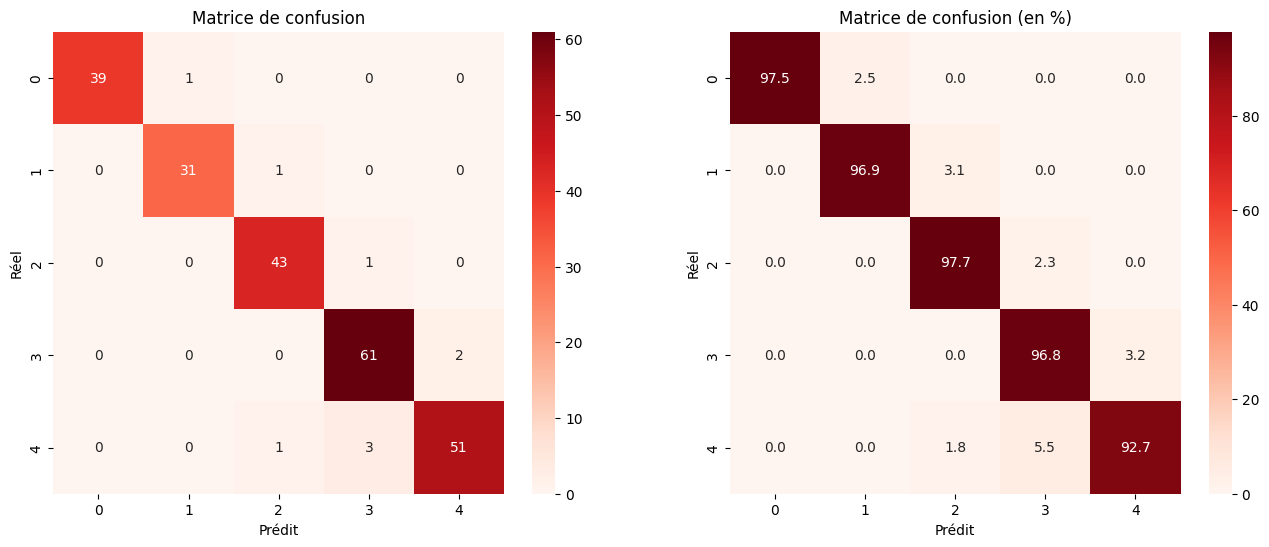

In [ ]:
y_pred_proba_tunning = model_tf_learn_tunning.predict(X_test)
plot_confusion_matrices_onehot(y_test, y_pred_proba_tunning)

Le modèle classe très bien l’ensemble des catégories, avec plus de 95 % de bonnes prédictions et seulement quelques confusions.
La classe 4 est la plus difficile à distinguer, car elle génère la majorité des erreurs vers les classes 2 et 3.

On peut faire une mise a jour de notre tableau obtenu dans la partie comparaison des modèle avec et sans data augmentation du transfert learning en mode futures extraction :

| Métrique | Sans Augmentation | Avec Augmentation | <font color="red"><b>Fine tuning</b></font> |
|----------|-------------------|-------------------|-------------------|
| **Accuracy Train** | 99.8% | 95.9% | <font color="red"><b>97.94%</b></font> |
| **Accuracy Test** | 94.1% | 93.2% | <font color="red"><b>97.55%</b></font> |
| **Loss Train** | 0.012 | 0.104 | <font color="red"><b>0.0826</b></font> |
| **Loss Test** | 0.605 | 0.323 | <font color="red"><b>0.0998</b></font> |
| **Écart Train-Test** | 5.7% | 2.7% | <font color="red"><b>0.39%</b></font> |
| **Nombre d'epochs** | 26 | 12 | <font color="red"><b>14</b></font> |

On constate clairement que la combinaison de la data augmentation et du fine-tuning permet d’obtenir les meilleures performances avec une précision élevée sur l’ensemble d’entraînement et de test. Ce qui confirme une excellente capacité de généralisation.

De plus, le nombre d’époques nécessaire pour atteindre cette performance reste relativement faible (14 epochs), ce qui montre que le modèle converge rapidement avec la méthode du fine-tuning grâce aux poids pré-entraînés.


